# Phase 5 — Counterfactual recourse (DiCE)

This notebook wires **dice-ml** to the saved **XGBoost + preprocessing** pipeline (`models/xgboost_pipeline.joblib`). **Age** and **sex** are fixed via `features_to_vary` (everything in `MODIFIABLE_FEATURES`). For **five** high-risk test patients (highest predicted risk among **true disease** cases in the hold-out split), we use the **genetic** DiCE method to propose **three** diverse counterfactuals each that push the model toward **low risk**, then tabulate changes, predicted risk, and a simple **recourse cost**.

> **Interview line:** *Counterfactuals turn a model score into decision support: a clinician can discuss “lower resting BP / LDL” rather than abstract feature indices.*

Run `notebook/modeling.ipynb` first if `models/xgboost_pipeline.joblib` is missing.

In [1]:
import sys
from pathlib import Path

import dice_ml
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dice_ml import Dice, Model
from IPython.display import display
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing import (
    FEATURE_COLUMNS,
    MODIFIABLE_FEATURES,
    NON_MODIFIABLE_FEATURES,
    TARGET_COLUMN,
    load_heart_csv,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

MODEL_PATH = ROOT / "models" / "xgboost_pipeline.joblib"
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Missing {MODEL_PATH} — run notebook/modeling.ipynb first.")

pipe = joblib.load(MODEL_PATH)

In [2]:
def coerce_int_float(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize raw dtypes before DiCE applies category / int32 typing."""
    out = df.copy()
    for c in FEATURE_COLUMNS:
        if c == "oldpeak":
            out[c] = out[c].astype(float)
        else:
            out[c] = out[c].astype(int)
    return out


def align_query_to_training_dtypes(
    df: pd.DataFrame, train_with_target: pd.DataFrame
) -> pd.DataFrame:
    """Match `dice_ml.Data` column dtypes (pandas `category` for discrete fields)."""
    ref = train_with_target.drop(columns=[TARGET_COLUMN])
    out = df.copy()
    for c in FEATURE_COLUMNS:
        if ref[c].dtype.name == "category":
            cats = [str(x) for x in ref[c].cat.categories]
            out[c] = pd.Categorical(out[c].astype(int).astype(str), categories=cats)
        else:
            out[c] = out[c].astype(ref[c].dtype)
    return out


def recourse_cost(
    orig: pd.Series,
    cf: pd.Series,
    train_X: pd.DataFrame,
    features: list[str],
) -> float:
    """Sum of normalized |Δ| on numeric features plus 1 per changed categorical level."""
    total = 0.0
    for f in features:
        col = train_X[f]
        if col.dtype.name == "category":
            total += 0.0 if str(orig[f]) == str(cf[f]) else 1.0
        else:
            lo, hi = float(col.min()), float(col.max())
            span = hi - lo if hi > lo else 1.0
            total += abs(float(cf[f]) - float(orig[f])) / span
    return float(total)

In [3]:
X, y = load_heart_csv(ROOT / "data" / "heart-disease.csv")
X = coerce_int_float(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

df_train = pd.concat([X_train, y_train.rename(TARGET_COLUMN)], axis=1)

CONTINUOUS_FOR_DICE = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "sex",
    "fbs",
    "exang",
]

d = dice_ml.Data(
    dataframe=df_train,
    continuous_features=CONTINUOUS_FOR_DICE,
    outcome_name=TARGET_COLUMN,
)
ref_features = d.data_df.drop(columns=[TARGET_COLUMN])

m = Model(model=pipe, backend="sklearn", model_type="classifier")
exp = Dice(d, m, method="genetic")

X_test_aligned = align_query_to_training_dtypes(X_test, df_train)
proba_test = pd.Series(
    pipe.predict_proba(X_test_aligned)[:, 1],
    index=X_test.index,
)

mask_pos = y_test.astype(int) == 1
candidates = proba_test[mask_pos].sort_values(ascending=False)
top_idx = candidates.index[:5].tolist()

FEATURES_TO_VARY = [c for c in MODIFIABLE_FEATURES]
NON_MODIFIABLE_FEATURES, top_idx[:3]

(('age', 'sex'), [142, 157, 12])

In [4]:
rows_summary: list[dict] = []
changes_rows: list[dict] = []

for rank, ix in enumerate(top_idx, start=1):
    query = X_test_aligned.loc[[ix]]
    cfs = exp.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=FEATURES_TO_VARY,
        stopping_threshold=0.5,
        maxiterations=45,
        verbose=False,
    )
    cf_df = cfs.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
    orig = query.iloc[0]
    for j in range(len(cf_df)):
        cf_row = cf_df.iloc[j].drop(labels=[TARGET_COLUMN], errors="ignore")
        aligned_cf = align_query_to_training_dtypes(cf_row.to_frame().T, df_train).iloc[0]
        p_cf = float(pipe.predict_proba(aligned_cf.to_frame().T)[0, 1])
        cost = recourse_cost(orig, aligned_cf, ref_features, FEATURES_TO_VARY)
        rows_summary.append(
            {
                "patient_rank": rank,
                "test_index": ix,
                "cf_k": j + 1,
                "p_before": float(proba_test.loc[ix]),
                "p_after": p_cf,
                "recourse_cost": cost,
            }
        )
        for f in FEATURE_COLUMNS:
            if str(orig[f]) != str(aligned_cf[f]):
                changes_rows.append(
                    {
                        "patient": rank,
                        "cf": j + 1,
                        "feature": f,
                        "before": orig[f],
                        "after": aligned_cf[f],
                    }
                )

summary = pd.DataFrame(rows_summary)
changes_df = pd.DataFrame(changes_rows)
display(summary)
display(changes_df.query("patient == 1").head(20))

100%|██████████| 1/1 [00:00<00:00,  5.64it/s]


,patient_rank,test_index,cf_k,p_before,p_after,recourse_cost
0,1,142,1,0.988724,0.624455,1.169473
1,1,142,2,0.988724,0.215340,2.695031
2,1,142,3,0.988724,0.501831,4.128706
3,2,157,1,0.981586,0.602476,1.505270
4,2,157,2,0.981586,0.222324,2.351422
5,2,157,3,0.981586,0.214408,2.521234
6,3,12,1,0.981200,0.341018,1.385817
7,3,12,2,0.981200,0.664347,1.552260
8,3,12,3,0.981200,0.337907,2.443115
9,4,41,1,0.976190,0.555565,2.444960


,patient,cf,feature,before,after
0,1,1,trestbps,120.0,150.0
1,1,1,chol,209.0,231.0
2,1,1,thalach,173.0,147.0
3,1,1,oldpeak,0.0,3.6
4,1,2,chol,209.0,188.0
5,1,2,thalach,173.0,139.0
6,1,2,oldpeak,0.0,2.0
7,1,2,ca,0.0,3.0
8,1,2,thal,2.0,3.0
9,1,3,cp,2.0,0.0


/var/folders/sr/9np2q2050_vbhbh8yzdj_6q00000gn/T/ipykernel_52995/2831428244.py:6: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/gabrielesantoro/heart-risk-advisor/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


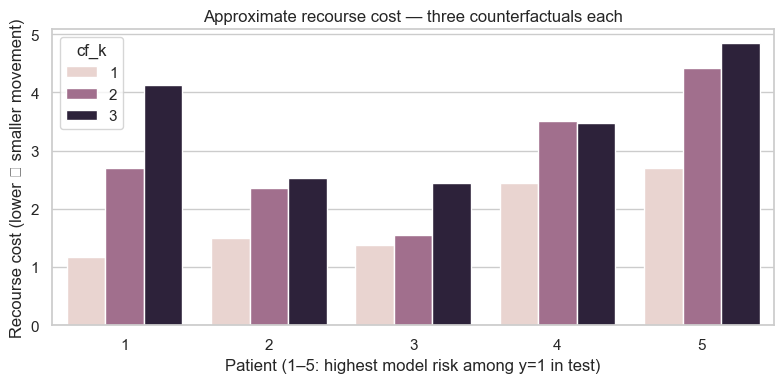

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=summary, x="patient_rank", y="recourse_cost", hue="cf_k", ax=ax)
ax.set_xlabel("Patient (1–5: highest model risk among y=1 in test)")
ax.set_ylabel("Recourse cost (lower ⇒ smaller movement)")
ax.set_title("Approximate recourse cost — three counterfactuals each")
plt.tight_layout()
plt.show()